## Load the Data

In [22]:
import pandas as pd
df = pd.read_csv("../data/raw/student_study_dataset.csv")
df.head()

,student_id,subject_id,difficulty,previous_score,days_until_exam,topics_remaining,available_hours_total,priority_weight,recommended_hours
0,0,0,2,75,37,4,4,2.7703,0.50
1,0,1,2,95,59,2,4,1.6695,0.29
2,0,2,3,95,43,6,4,3.3326,0.60
3,0,3,5,86,57,4,4,3.6554,0.63
4,0,4,1,94,44,3,4,1.6473,0.31


## Basic Data Inspection

In [23]:
df.shape

(12029, 9)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12029 entries, 0 to 12028
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             12029 non-null  int64  
 1   subject_id             12029 non-null  int64  
 2   difficulty             12029 non-null  int64  
 3   previous_score         12029 non-null  int64  
 4   days_until_exam        12029 non-null  int64  
 5   topics_remaining       12029 non-null  int64  
 6   available_hours_total  12029 non-null  int64  
 7   priority_weight        12029 non-null  float64
 8   recommended_hours      12029 non-null  float64
dtypes: float64(2), int64(7)
memory usage: 845.9 KB


In [25]:
df.describe()

,student_id,subject_id,difficulty,previous_score,days_until_exam,topics_remaining,available_hours_total,priority_weight,recommended_hours
count,12029.000000,12029.000000,12029.000000,12029.000000,12029.000000,12029.000000,12029.000000,12029.000000,12029.000000
mean,1007.471943,3.043977,3.007565,76.593150,32.662233,6.008480,5.428548,3.932902,0.897398
std,580.398616,2.426843,1.410691,10.380798,16.112773,2.129635,1.729549,0.978336,0.592857
min,0.000000,0.000000,1.000000,37.000000,5.000000,2.000000,3.000000,1.275400,0.110000
25%,503.000000,1.000000,2.000000,69.000000,19.000000,5.000000,4.000000,3.234100,0.510000
50%,1017.000000,3.000000,3.000000,77.000000,33.000000,6.000000,5.000000,3.920000,0.740000
75%,1512.000000,5.000000,4.000000,84.000000,47.000000,7.000000,7.000000,4.590000,1.080000
max,1999.000000,9.000000,5.000000,95.000000,60.000000,15.000000,8.000000,8.640000,5.580000


In [26]:
df.isnull().sum()

student_id               0
subject_id               0
difficulty               0
previous_score           0
days_until_exam          0
topics_remaining         0
available_hours_total    0
priority_weight          0
recommended_hours        0
dtype: int64

## Check the Allocated Hours Constraint

In [27]:
check = df.groupby("student_id").agg({
    "recommended_hours":"sum",
    "available_hours_total":"first"
})

check.head()

,recommended_hours,available_hours_total
student_id,,
0,4.01,4
1,7.03,7
2,6.07,6
3,7.94,8
4,6.96,7


In [28]:
(check["recommended_hours"]-check["available_hours_total"]).abs().mean()

np.float64(0.05634999999999996)

## Distribution Plots

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

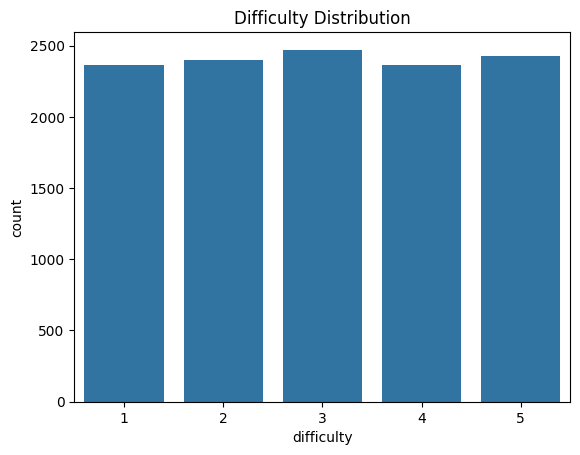

In [30]:
sns.countplot(x = "difficulty", data = df)
plt.title("Difficulty Distribution")
plt.show()

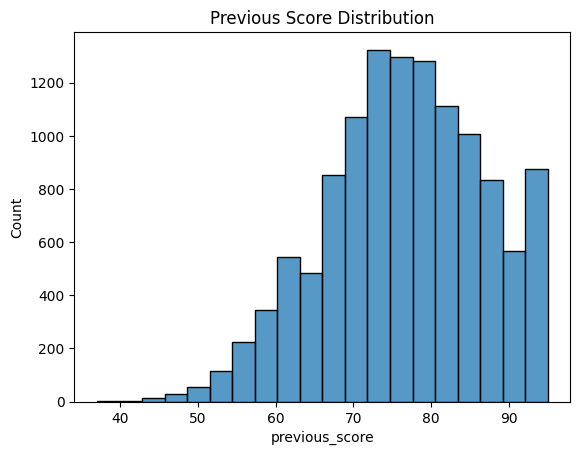

In [31]:
sns.histplot(df["previous_score"], bins=20)
plt.title("Previous Score Distribution")
plt.show()

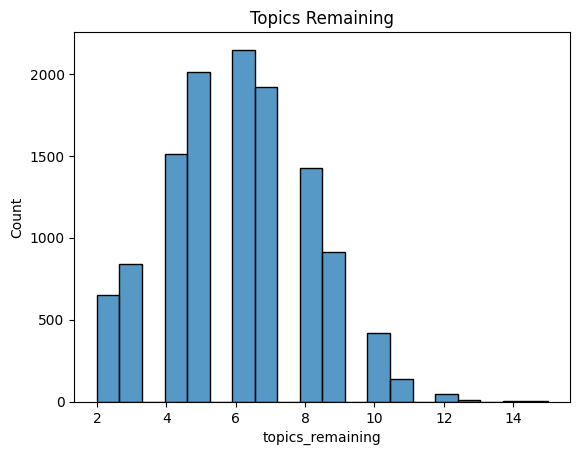

In [32]:
sns.histplot(df["topics_remaining"], bins=20)
plt.title("Topics Remaining")
plt.show()

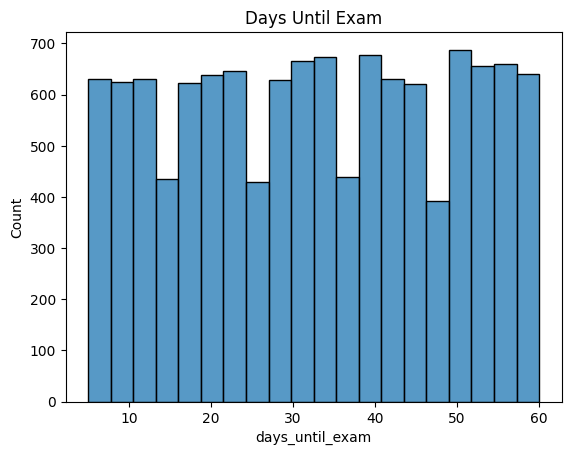

In [33]:
sns.histplot(df["days_until_exam"], bins=20)
plt.title("Days Until Exam")
plt.show()

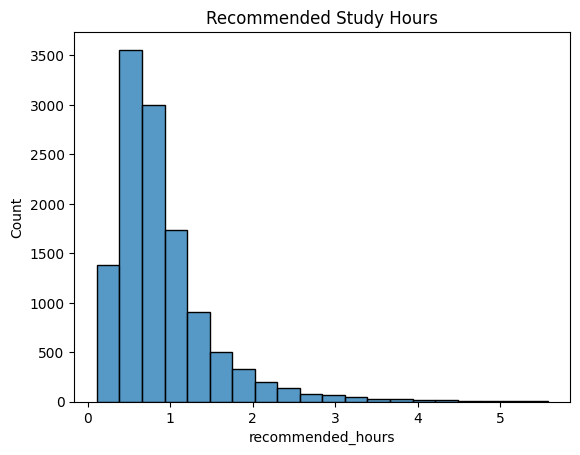

In [34]:
sns.histplot(df["recommended_hours"], bins=20)
plt.title("Recommended Study Hours")
plt.show()

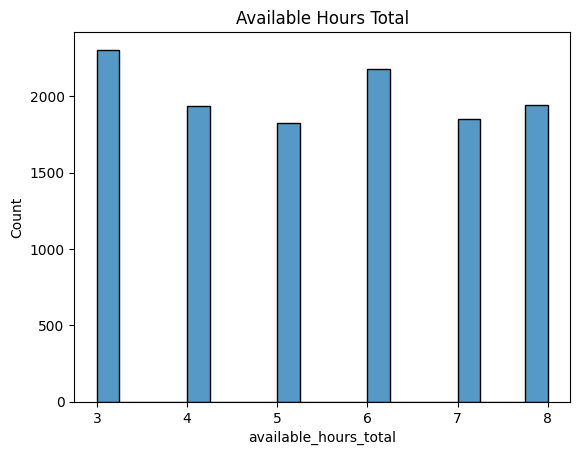

In [35]:
sns.histplot(df["available_hours_total"], bins=20)
plt.title("Available Hours Total")
plt.show()

## Feature Relationships

### Difficulty vs Study Hours

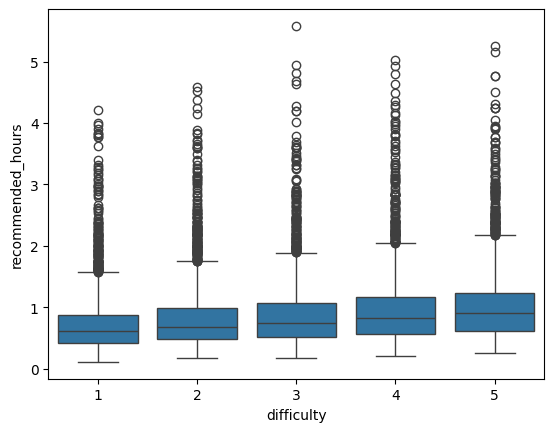

In [36]:
sns.boxplot(x="difficulty", y = "recommended_hours", data=df)
plt.show()

### Topics Remaining vs Study Hours

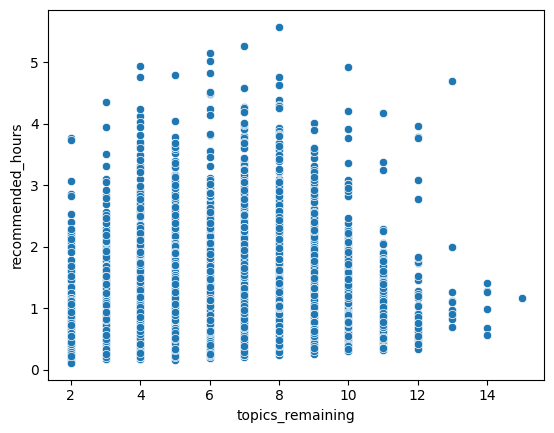

In [37]:
sns.scatterplot(
    x = "topics_remaining",
    y = "recommended_hours",
    data = df
)
plt.show()

### Previous Score vs Study Hours

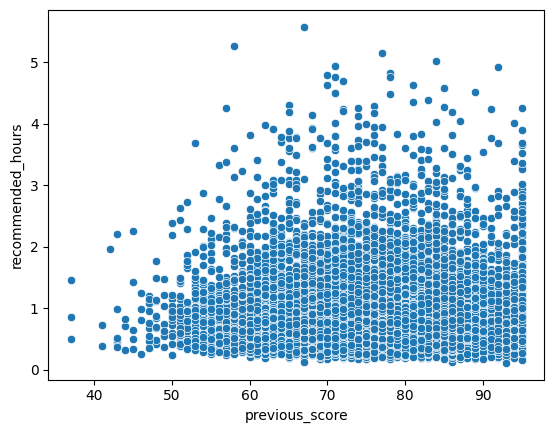

In [38]:
sns.scatterplot(
    x = "previous_score",
    y = "recommended_hours",
    data = df
)
plt.show()

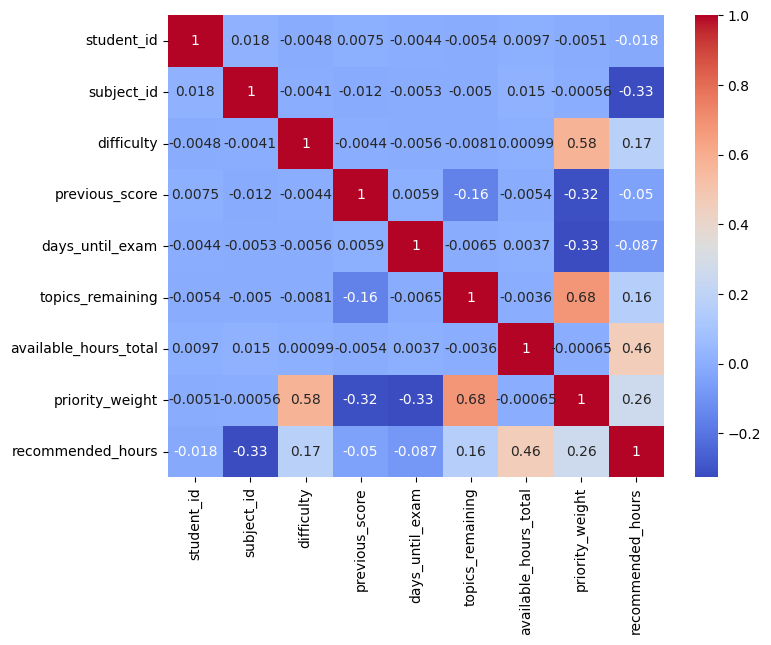

In [39]:
corr = df.corr(numeric_only = True)
plt.figure(figsize = (8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [40]:
df_processed = df.copy()
df_processed.to_csv(
    "../data/processed/processed_study_dataset.csv",
    index=False
)